# Market Basket Analysis for Store Data

## Project Objective
This notebook performs **Market Basket Analysis (MBA)** on store transaction data using the **Apriori algorithm** and **Association Rule Mining**.

The goal is to identify products that are frequently purchased together so that a store can use the insights for:
- Product bundling
- Cross-selling
- Shelf placement
- Promotional offers
- Recommendation strategy


In [1]:
# Install mlxtend if it is not already installed
import sys
import subprocess
import importlib.util

if importlib.util.find_spec("mlxtend") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "mlxtend"])

In [2]:
# Import required libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)

/home/oai/.config/matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-r63vcm86 because there was an issue with the default path (/home/oai/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


## Load Dataset

The dataset contains store transactions. Each row represents one transaction, and each column contains an item purchased in that transaction.


In [3]:
# Load dataset
DATA_PATH = "store_data.csv"

if not os.path.exists(DATA_PATH):
    DATA_PATH = "/mnt/data/store_data.csv"

df = pd.read_csv(DATA_PATH, header=None)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (7501, 20)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,shrimp,almonds,avocado,vegetables mix,green grapes,whole weat flour,yams,cottage cheese,energy drink,tomato juice,low fat yogurt,green tea,honey,salad,mineral water,salmon,antioxydant juice,frozen smoothie,spinach,olive oil
1,burgers,meatballs,eggs,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,chutney,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,turkey,avocado,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,mineral water,milk,energy bar,whole wheat rice,green tea,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# Basic dataset information
print("Number of transactions:", df.shape[0])
print("Maximum items in a transaction:", df.shape[1])
print("Total missing cells:", df.isna().sum().sum())

Number of transactions: 7501
Maximum items in a transaction: 20
Total missing cells: 120657


## Convert Data into Transaction Format

The Apriori algorithm requires each transaction to be represented as a list of items. Missing values are removed, item names are stripped of extra spaces, and duplicate items inside the same transaction are removed as Apriori doesn't depend on frequency but only on presence/absence of the item.


In [5]:
# Convert rows into transaction lists
transactions = []

for i in range(len(df)):
    transaction = (
        df.iloc[i]
        .dropna()
        .astype(str)
        .str.strip()
        .tolist()
    )

    # Remove empty strings and duplicate items in the same transaction
    cleaned_transaction = []
    for item in transaction:
        if item and item.lower() != "nan" and item not in cleaned_transaction:
            cleaned_transaction.append(item)

    transactions.append(cleaned_transaction)

print("Total transactions prepared:", len(transactions))
print("First 3 transactions:")
transactions[:3]

Total transactions prepared: 7501
First 3 transactions:


[['shrimp',
  'almonds',
  'avocado',
  'vegetables mix',
  'green grapes',
  'whole weat flour',
  'yams',
  'cottage cheese',
  'energy drink',
  'tomato juice',
  'low fat yogurt',
  'green tea',
  'honey',
  'salad',
  'mineral water',
  'salmon',
  'antioxydant juice',
  'frozen smoothie',
  'spinach',
  'olive oil'],
 ['burgers', 'meatballs', 'eggs'],
 ['chutney']]

## One-Hot Encoding

Market Basket Analysis requires transaction data in a one-hot encoded format, where each column represents an item and each row shows whether that item was present in the transaction.


In [6]:
# One-hot encode transaction data
te = TransactionEncoder()
encoded_array = te.fit(transactions).transform(transactions)

df_encoded = pd.DataFrame(encoded_array, columns=te.columns_)

print("Encoded dataset shape:", df_encoded.shape)
df_encoded.head()

Encoded dataset shape: (7501, 119)


,almonds,antioxydant juice,asparagus,avocado,babies food,bacon,barbecue sauce,black tea,blueberries,body spray,bramble,brownies,bug spray,burger sauce,burgers,butter,cake,candy bars,carrots,cauliflower,cereals,champagne,chicken,chili,chocolate,chocolate bread,chutney,cider,clothes accessories,cookies,cooking oil,corn,cottage cheese,cream,dessert wine,eggplant,eggs,energy bar,energy drink,escalope,extra dark chocolate,flax seed,french fries,french wine,fresh bread,fresh tuna,fromage blanc,frozen smoothie,frozen vegetables,gluten free bar,grated cheese,green beans,green grapes,green tea,ground beef,gums,ham,hand protein bar,herb & pepper,honey,hot dogs,ketchup,light cream,light mayo,low fat yogurt,magazines,mashed potato,mayonnaise,meatballs,melons,milk,mineral water,mint,mint green tea,muffins,mushroom cream sauce,napkins,nonfat milk,oatmeal,oil,olive oil,pancakes,parmesan cheese,pasta,pepper,pet food,pickles,protein bar,red wine,rice,salad,salmon,salt,sandwich,shallot,shampoo,shrimp,soda,soup,spaghetti,sparkling water,spinach,strawberries,strong cheese,tea,tomato juice,tomato sauce,tomatoes,toothpaste,turkey,vegetables mix,water spray,white wine,whole weat flour,whole wheat pasta,whole wheat rice,yams,yogurt cake,zucchini
0,True,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,True,True,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,True,False,False,False,False,True,False,False,False,False,True,False,False,False,True,False,False,False,False,True,False,False,True,False,False,True,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,Fal

In [7]:
# Count unique items
print("Total unique items:", df_encoded.shape[1])

Total unique items: 119


## Frequent Itemset Mining using Apriori

`min_support = 0.01` means an itemset must appear in at least 1% of total transactions to be considered frequent.


In [8]:
# Generate frequent itemsets
MIN_SUPPORT = 0.01

frequent_itemsets = apriori(
    df_encoded,
    min_support=MIN_SUPPORT,
    use_colnames=True
)

frequent_itemsets["itemset_length"] = frequent_itemsets["itemsets"].apply(lambda x: len(x))
frequent_itemsets_sorted = frequent_itemsets.sort_values(by="support", ascending=False).reset_index(drop=True)

print("Number of frequent itemsets:", frequent_itemsets_sorted.shape[0])
frequent_itemsets_sorted.head(10)

Number of frequent itemsets: 257


,support,itemsets,itemset_length
0,0.238368,frozenset({mineral water}),1
1,0.179709,frozenset({eggs}),1
2,0.174110,frozenset({spaghetti}),1
3,0.170911,frozenset({french fries}),1
4,0.163845,frozenset({chocolate}),1
5,0.132116,frozenset({green tea}),1
6,0.129583,frozenset({milk}),1
7,0.098254,frozenset({ground beef}),1
8,0.095321,frozenset({frozen vegetables}),1
9,0.095054,frozenset({pancakes}),1


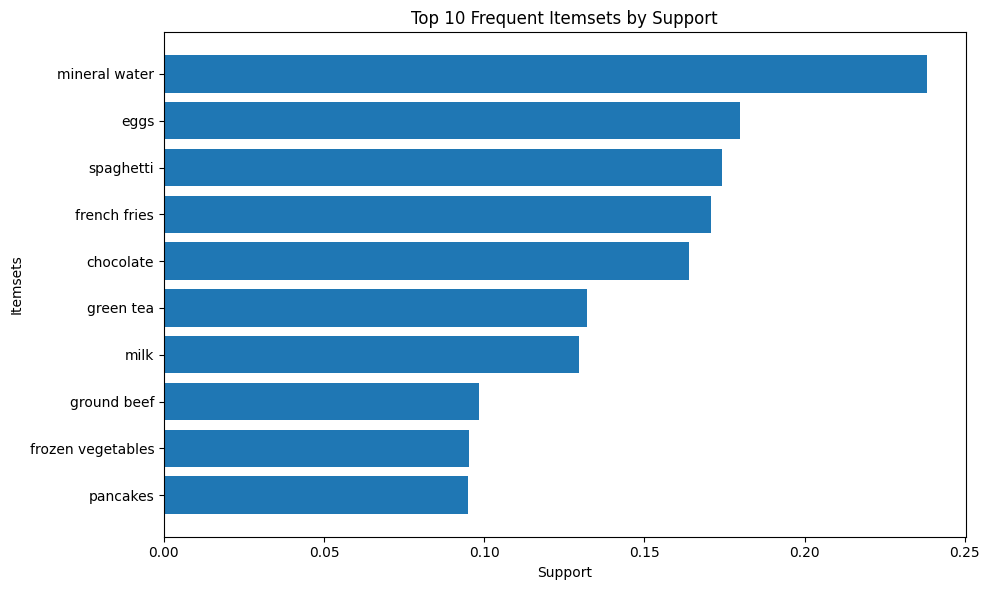

In [9]:
# Visualize top 10 frequent itemsets
top_itemsets = frequent_itemsets_sorted.head(10).copy()
top_itemsets["itemsets"] = top_itemsets["itemsets"].apply(lambda x: ", ".join(list(x)))

plt.figure(figsize=(10, 6))
plt.barh(top_itemsets["itemsets"], top_itemsets["support"])
plt.xlabel("Support")
plt.ylabel("Itemsets")
plt.title("Top 10 Frequent Itemsets by Support")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Association Rule Mining

Association rules are generated using lift as the main metric.

Important metrics:
- **Support:** How often the item combination appears in all transactions.
- **Confidence:** Probability of buying the consequent when the antecedent is purchased.
- **Lift:** Strength of the rule compared to random chance. A lift greater than 1 indicates a useful positive association.


In [10]:
# Generate association rules
rules = association_rules(
    frequent_itemsets,
    metric="lift",
    min_threshold=1
)

rules_sorted = rules.sort_values(by=["lift", "confidence"], ascending=False).reset_index(drop=True)

print("Number of association rules generated:", rules_sorted.shape[0])

rules_display = rules_sorted[
    ["antecedents", "consequents", "support", "confidence", "lift"]
].copy()

rules_display.head(10)

Number of association rules generated: 406


,antecedents,consequents,support,confidence,lift
0,frozenset({herb & pepper}),frozenset({ground beef}),0.015998,0.323450,3.291994
1,frozenset({ground beef}),frozenset({herb & pepper}),0.015998,0.162822,3.291994
2,"frozenset({spaghetti, mineral water})",frozenset({ground beef}),0.017064,0.285714,2.907928
3,frozenset({ground beef}),"frozenset({spaghetti, mineral water})",0.017064,0.173677,2.907928
4,"frozenset({spaghetti, mineral water})",frozenset({olive oil}),0.010265,0.171875,2.609786
5,frozenset({olive oil}),"frozenset({spaghetti, mineral water})",0.010265,0.155870,2.609786
6,frozenset({tomatoes}),frozenset({frozen vegetables}),0.016131,0.235867,2.474464
7,frozenset({frozen vegetables}),frozenset({tomatoes}),0.016131,0.169231,2.474464
8,frozenset({shrimp}),frozenset({frozen vegetables}),0.016664,0.233209,2.446574
9,frozenset({frozen vegetables}),frozenset({shrimp}),0.016664,0.174825,2.446574


In [11]:
# Convert frozensets to readable strings for export and display
rules_export = rules_sorted.copy()
rules_export["antecedents"] = rules_export["antecedents"].apply(lambda x: ", ".join(list(x)))
rules_export["consequents"] = rules_export["consequents"].apply(lambda x: ", ".join(list(x)))

frequent_itemsets_export = frequent_itemsets_sorted.copy()
frequent_itemsets_export["itemsets"] = frequent_itemsets_export["itemsets"].apply(lambda x: ", ".join(list(x)))

rules_export.to_csv("mba_association_rules.csv", index=False)
frequent_itemsets_export.to_csv("mba_frequent_itemsets.csv", index=False)

print("Files exported:")
print("mba_association_rules.csv")
print("mba_frequent_itemsets.csv")

Files exported:
mba_association_rules.csv
mba_frequent_itemsets.csv


In [12]:
# Top 10 rules by lift
top_rules = rules_export[
    ["antecedents", "consequents", "support", "confidence", "lift"]
].head(10)

top_rules

,antecedents,consequents,support,confidence,lift
0,herb & pepper,ground beef,0.015998,0.323450,3.291994
1,ground beef,herb & pepper,0.015998,0.162822,3.291994
2,"spaghetti, mineral water",ground beef,0.017064,0.285714,2.907928
3,ground beef,"spaghetti, mineral water",0.017064,0.173677,2.907928
4,"spaghetti, mineral water",olive oil,0.010265,0.171875,2.609786
5,olive oil,"spaghetti, mineral water",0.010265,0.155870,2.609786
6,tomatoes,frozen vegetables,0.016131,0.235867,2.474464
7,frozen vegetables,tomatoes,0.016131,0.169231,2.474464
8,shrimp,frozen vegetables,0.016664,0.233209,2.446574
9,frozen vegetables,shrimp,0.016664,0.174825,2.446574


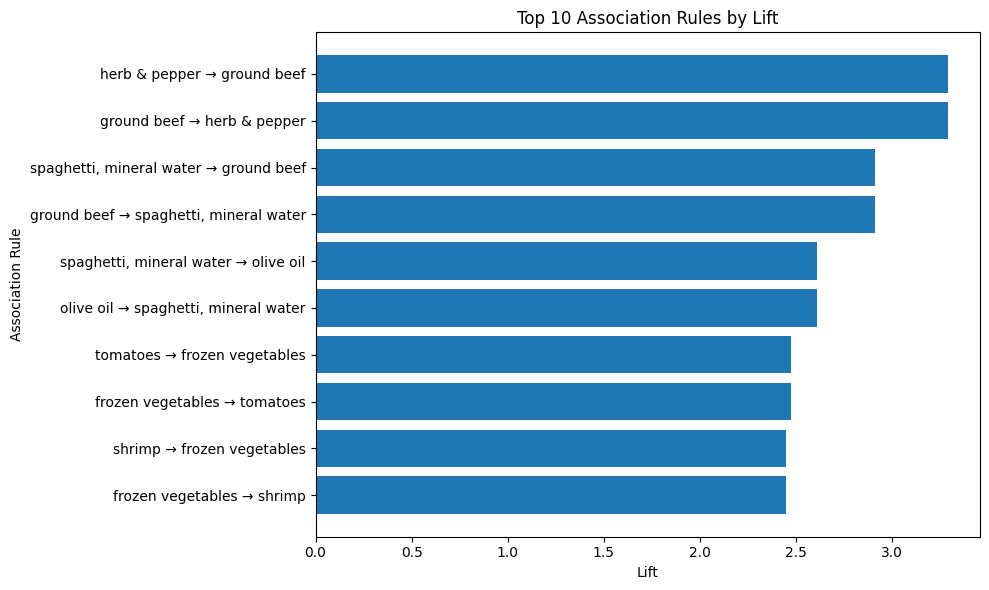

In [13]:
# Visualize top 10 association rules by lift
plot_rules = top_rules.copy()
plot_rules["rule"] = plot_rules["antecedents"] + " → " + plot_rules["consequents"]

plt.figure(figsize=(10, 6))
plt.barh(plot_rules["rule"], plot_rules["lift"])
plt.xlabel("Lift")
plt.ylabel("Association Rule")
plt.title("Top 10 Association Rules by Lift")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Observations

1. The dataset contains **7,501 transactions** and a maximum of **20 item columns** per transaction.
2. After preprocessing, **119 unique items** were identified.
3. Using a minimum support of **1%**, the Apriori algorithm generated **257 frequent itemsets**.
4. The analysis generated **406 association rules** with lift greater than or equal to 1.
5. The most frequently purchased item was **mineral water**, followed by items such as **eggs, spaghetti, french fries, chocolate, green tea, and milk**.
6. High-lift rules indicate product combinations that are purchased together more often than random chance.
7. These high-lift rules can be useful for cross-selling, bundled offers, shelf arrangement, and promotional planning.


## Conclusion

The Market Basket Analysis successfully identified frequently purchased products and meaningful association rules from store transaction data.

The Apriori algorithm helped discover common item combinations, while the association rules provided insights into which products are likely to be bought together. These insights can support retail decision-making, especially in product placement, recommendation systems, combo offers, and targeted promotions.

Overall, this project demonstrates how association rule mining can be applied to retail transaction data to generate practical business insights.
